<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>03 - Facial Expression Recognition with Keras</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">CNN to Recognize Human Facial Expressions in Real Time with OpenCV and Flask</span>
</div>

<div align="center">
  <a href="https://colab.research.google.com/github/mohd-faizy/03P_Facial_Expression_Recoginition/blob/master/01_Facial_Expression_Recoginition_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</div>

---

# Table of Contents

1. [Environment Setup & Dataset Acquisition](#1-environment-setup--dataset-acquisition)
   - 1.1 [Download Project Dataset](#11-download-project-dataset)
   - 1.2 [Dataset Acquisition & Extraction](#12-dataset-acquisition-and-extraction)
   - 1.3 [Verify Dataset Structure](#13-verify-dataset-structure)
   - 1.4 [Install Project Dependencies](#14-install-project-dependencies)
2. [Task 1: Import Libraries & Hardware Setup](#2-task-1-import-libraries--hardware-setup)
   - 2.1 [Import Core Libraries & TensorFlow Backend](#21-import-core-libraries--tensorflow-backend)
3. [Task 2: Exploratory Data Analysis & Sample Visualization](#3-task-2-exploratory-data-analysis--sample-visualization)
   - 3.1 [Plot Example Facial Expressions](#31-plot-example-facial-expressions)
   - 3.2 [Class Distribution & Imbalance Analysis](#32-class-distribution--imbalance-analysis)
4. [Task 3: Generate Training & Validation Batches](#4-task-3-generate-training--validation-batches)
   - 4.1 [Batch Size & Hyperparameter Guidelines](#41-batch-size--hyperparameter-guidelines)
   - 4.2 [Real-Time Data Augmentation with ImageDataGenerator](#42-real-time-data-augmentation-with-imagedatagenerator)
   - 4.3 [Categorical One-Hot Encoding & Validation Settings](#43-categorical-one-hot-encoding--validation-settings)
5. [Task 4: Design Deep CNN Architecture](#5-task-4-design-deep-cnn-architecture)
   - 5.1 [Architecture Overview & Literature Reference](#51-architecture-overview--literature-reference)
   - 5.2 [Construct & Compile Deep CNN with Keras](#52-construct--compile-deep-cnn-with-keras)
6. [Task 5: Train and Evaluate Model](#6-task-5-train-and-evaluate-model)
   - 6.1 [Model Checkpointing & Learning Rate Scheduling](#61-model-checkpointing--learning-rate-scheduling)
   - 6.2 [Execute Model Training with Live Loss Monitoring](#62-execute-model-training-with-live-loss-monitoring)
   - 6.3 [Keras Training Callbacks & Reference](#63-keras-training-callbacks--reference)
7. [Task 6: Serialize Model Architecture to JSON](#7-task-6-serialize-model-architecture-to-json)
   - 7.1 [Export Model Architecture to JSON String](#71-export-model-architecture-to-json-string)
8. [Task 7: Real-Time Inference Flask Application](#8-task-7-real-time-inference-flask-application)
   - 8.1 [Camera Video Stream Processing (src/camera.py)](#81-camera-video-stream-processing-srccamerapy)
   - 8.2 [Facial Expression Inference Engine (src/model.py)](#82-facial-expression-inference-engine-srcmodelpy)
   - 8.3 [HTML Web Interface Template (templates/index.html)](#83-html-web-interface-template-templatesindexhtml)
   - 8.4 [Deploy & Run Real-Time Flask Server (main.py)](#84-deploy--run-real-time-flask-server-mainpy)
9. [Project Summary & Key Takeaways](#9-project-summary--key-takeaways)

---

<a id="1-environment-setup--dataset-acquisition"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Environment Setup & Dataset Acquisition</span>

<a id="11-download-project-dataset"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.1 Download Project Dataset</span>

The project dataset containing facial expression training/testing images and the custom helper module (`utils`) is available via the link below:

- **Download Link**: [Project Dataset Folder (Dropbox)](https://www.dropbox.com/s/rzy7401554q57gg/Project.zip)

<a id="12-dataset-acquisition-and-extraction"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.2 Dataset Acquisition & Extraction</span>

Fetch the project dataset archive directly from Dropbox, unzip it, and set up `train/`, `test/`, and `utils/` in the project root directory for seamless local or Colab training.

In [1]:
# 1. Download Project.zip from Dropbox directly into the environment
!curl -L -o Project.zip "https://www.dropbox.com/scl/fi/zpamlummigq0a74aqcmu8/Project.zip?rlkey=h9hn0qr10pxulmtrh4frv2ryw&dl=1"

# 2. Unzip the project archive (contains train/, test/, and utils/)
!unzip -uq Project.zip

# 3. Copy extracted folders (train, test, utils) into the project directory
!cp -rn Project/train . 2>/dev/null || cp -r Project/train .
!cp -rn Project/test . 2>/dev/null || cp -r Project/test .
!cp -rn Project/utils . 2>/dev/null || cp -r Project/utils .

# 4. Clean up temporary archive and extracted root folder
!rm -rf Project.zip Project
print("✅ Dataset and utils successfully downloaded and extracted!")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     36      0 --:--:-- --:--:-- --:--:--    36
100   475    0   475    0     0    404      0 --:--:--  0:00:01 --:--:--     0
100  112M  100  112M    0     0  36.5M      0  0:00:03  0:00:03 --:--:-- 55.3M
✅ Dataset and utils successfully downloaded and extracted!


<a id="13-verify-dataset-structure"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.3 Verify Dataset Structure</span>

Confirm that the training and validation dataset splits are present and display the number of classes available for training.

In [ ]:
# Verify working directory and extracted dataset splits
import os

print(f"Working Directory: {os.getcwd()}")
for split in ['train', 'test']:
    if os.path.exists(split):
        classes = sorted(os.listdir(split))
        print(f"✅ Found '{split}/' directory with {len(classes)} classes: {classes}")
    else:
        print(f"❌ '{split}/' directory missing!")

if os.path.exists('utils'):
    print("✅ Found 'utils/' helper module.")
else:
    print("❌ 'utils/' module missing!")

Working Directory: /content
✅ Found 'train/' directory with 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ Found 'test/' directory with 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ Found 'utils/' helper module.


> [!TIP]
> **Alternative: Python Package Import via `sys.path`**  
> If you prefer not to change the working directory, you can dynamically append your module directory to `sys.path`:
> ```python
> import sys
> sys.path.insert(0, '/the/folder/path/name-package/')
> ```
> Ensure an `__init__.py` exists in the target directory so Python recognizes it as an importable package.

<a id="2-task-1-import-libraries--hardware-setup"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 1: Import Libraries & Hardware Setup</span>

<a id="21-import-core-libraries--tensorflow-backend"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 Import Core Libraries & TensorFlow Backend</span>

In [3]:
!pip install livelossplot  -q # for google colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.0/639.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.17.1 which is incompatible.


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils

%matplotlib inline

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from IPython.display import SVG, Image
from livelossplot import PlotLossesKerasTF

In [6]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<a id="3-task-2-exploratory-data-analysis--sample-visualization"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 2: Exploratory Data Analysis & Sample Visualization</span>

<a id="31-plot-example-facial-expressions"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Plot Example Facial Expressions</span>

- Utilizing the custom helper module `utils.datasets.fer` to inspect sample facial expressions across classes.
- `.fer` denotes **Facial Expression Recognition** across the seven canonical emotion categories (`angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`).

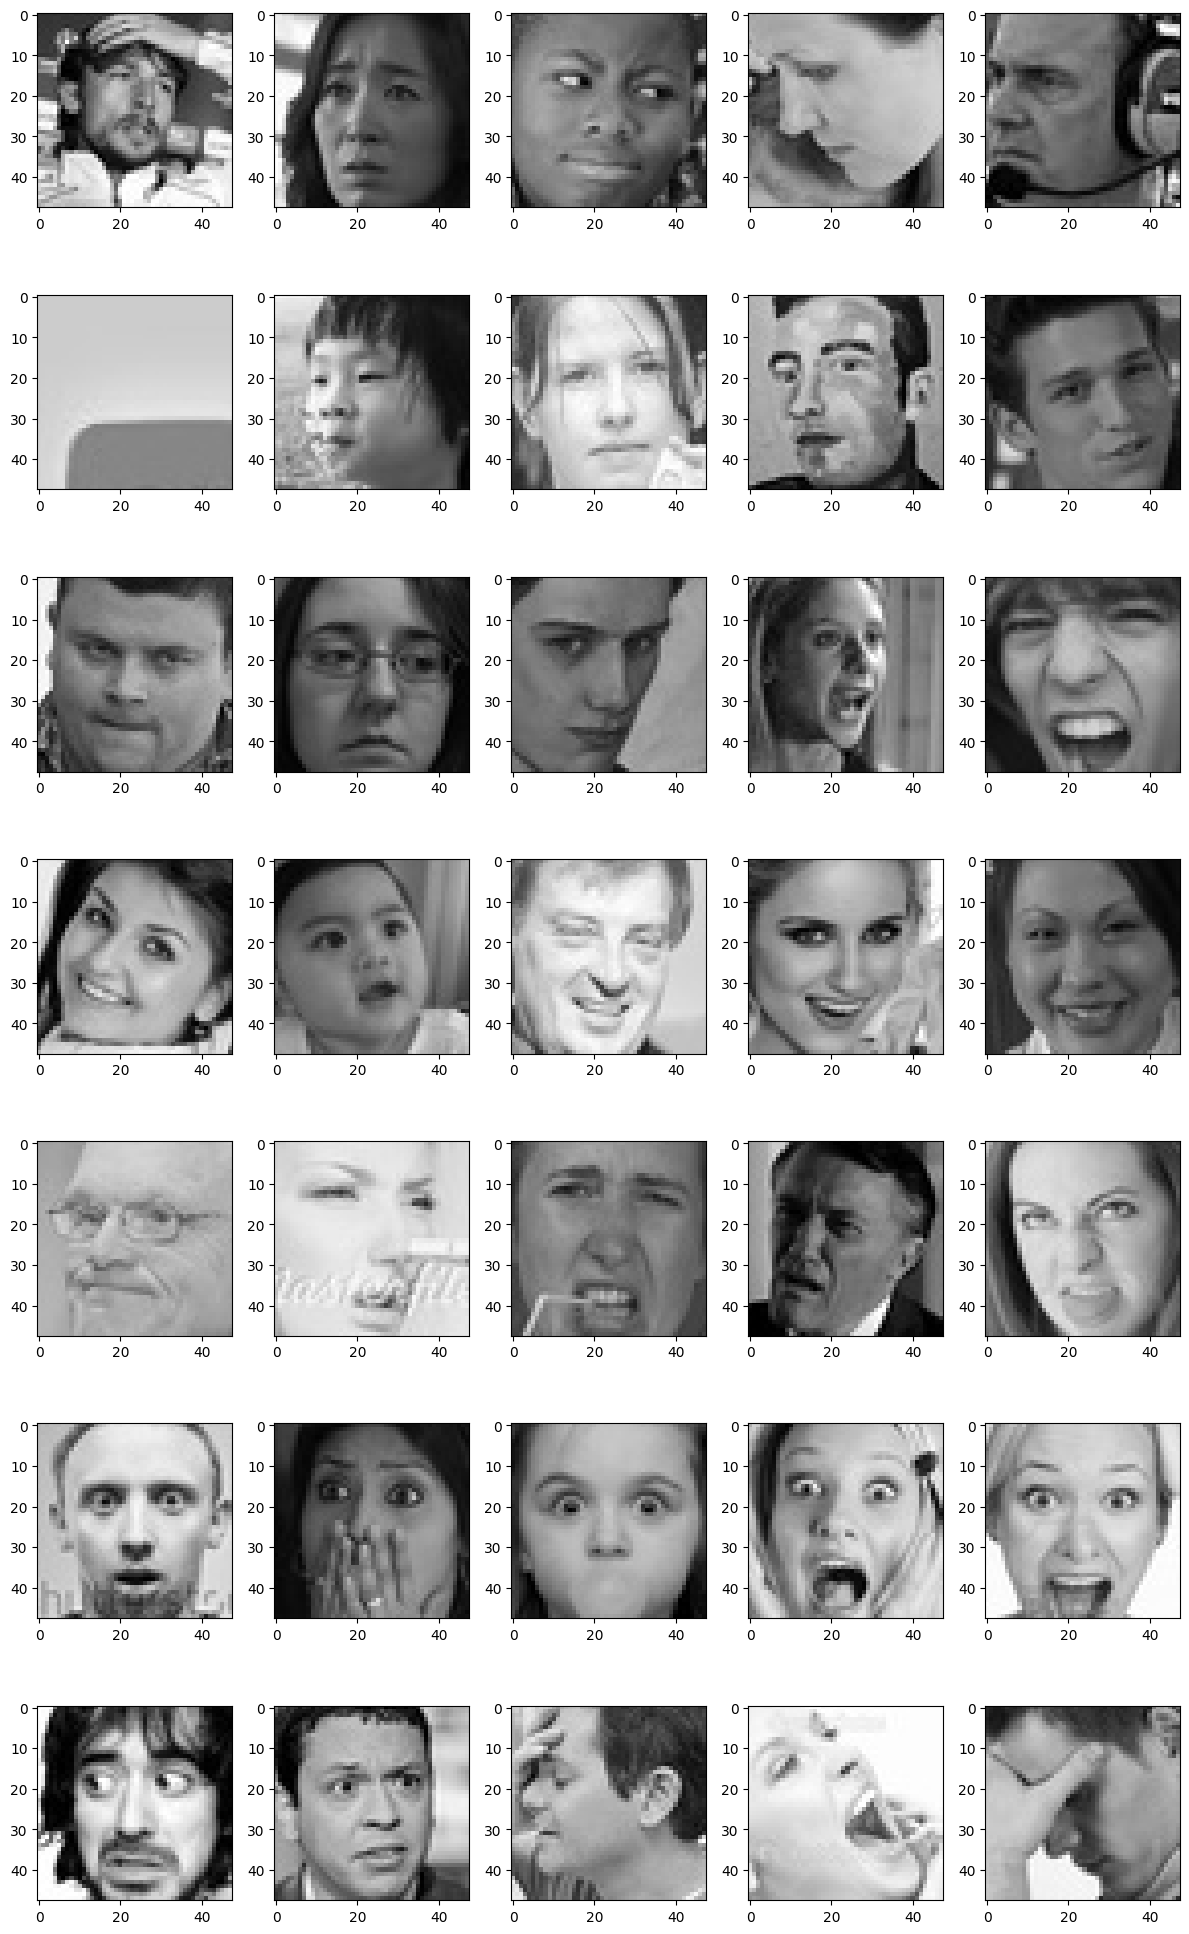

In [7]:
# Plot example facial expression images for each emotion category
utils.datasets.fer.plot_example_images(plt).show()

<a id="32-class-distribution--imbalance-analysis"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 Class Distribution & Imbalance Analysis</span>

- Inspecting the training set for **class imbalance**.
- Class imbalance can skew predictions toward majority classes. Data augmentation or class weighting can be used to mitigate minority class representation issues.

> [!NOTE]
> **Data Augmentation**: A strategy used to artificially increase the diversity and quantity of training data by applying random transformations (flips, rotations, shifts, zooms) to existing samples.

In [8]:
# Checking the class distribution for the training set
for expression in os.listdir('train/'):
    count = len(os.listdir(os.path.join('train', expression)))
    print(f"{count} {expression} images")

4830 sad images
4965 neutral images
3995 angry images
7215 happy images
436 disgust images
3171 surprise images
4097 fear images


> [!IMPORTANT]
> **Observation**: The output demonstrates that the **disgust** class contains only 436 images, which is substantially lower than the other categories (which average ~4,000+ images). We will use real-time data augmentation during training to assist generalization.

<a id="4-task-3-generate-training--validation-batches"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 3: Generate Training & Validation Batches</span>

<a id="41-batch-size--hyperparameter-guidelines"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 Batch Size & Hyperparameter Guidelines</span>

- **Image Resolution**: The FER-2013 dataset consists of `48 x 48` grayscale facial crops, so `img_size` is configured to 48.
- **Batch Size**: Configured to `64` to balance gradient estimate quality with GPU compute throughput.

| Gradient Descent Type | Batch Size Definition | Memory & Convergence Trade-off |
| :--- | :--- | :--- |
| **Batch Gradient Descent** | Batch Size = Size of Entire Training Set | Stable gradient, high memory, slow updates |
| **Stochastic Gradient Descent (SGD)** | Batch Size = 1 | Fast updates, high variance, noisy loss trajectory |
| **Mini-Batch Gradient Descent** | $1 < 	ext{Batch Size} < 	ext{Training Size}$ *(e.g., 32, 64, 128)* | Optimal balance of vectorization, stability, and speed |

<a id="42-real-time-data-augmentation-with-imagedatagenerator"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.2 Real-Time Data Augmentation with ImageDataGenerator</span>

We use Keras `ImageDataGenerator` with horizontal flipping to augment facial images on the fly during training.

In [9]:
img_size = 48
batch_size = 64

# Training Data Generator with random horizontal flip augmentation
datagen_train = ImageDataGenerator(horizontal_flip=True)
train_generator = datagen_train.flow_from_directory(
    'train/',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
    )

# Validation Data Generator
datagen_validation = ImageDataGenerator(horizontal_flip=True)
validation_generator = datagen_validation.flow_from_directory(
    'test/',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
    )

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


<a id="43-categorical-one-hot-encoding--validation-settings"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.3 Categorical One-Hot Encoding & Validation Settings</span>

- `class_mode='categorical'`: One-hot encodes the 7 target emotion classes into 7-dimensional binary vectors where the correct class index is `1` and all other entries are `0`.
- `shuffle=False` in `validation_generator`: Ensures the validation order remains deterministic for reproducible metric evaluation and confusion matrix generation.

<a id="5-task-4-design-deep-cnn-architecture"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 4: Design Deep CNN Architecture</span>

<a id="51-architecture-overview--literature-reference"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Architecture Overview & Literature Reference</span>

<div align="center" style="margin: 16px 0;">
  <img src="assets/model.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.25); max-width: 100%; height: auto;" alt="CNN Architecture Diagram">
</div>

> **Theoretical Reference:**  
> Goodfellow, I.J., et al. (2013). *Challenges in representation learning: A report of three machine learning contests.* Neural Networks, 64, 59-63. [doi:10.1016/j.neunet.2014.09.005](https://arxiv.org/pdf/1307.0414.pdf)

<a id="52-construct--compile-deep-cnn-with-keras"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Construct & Compile Deep CNN with Keras</span>

The deep network consists of 4 convolutional blocks followed by 2 dense fully connected layers and a 7-way softmax classification layer:
- **Block 1**: Input (48x48x1) $
ightarrow$ Conv2D (64 filters, 3x3) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ MaxPool2D (2x2) $
ightarrow$ Dropout (0.25)
- **Block 2**: Conv2D (128 filters, 5x5) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ MaxPool2D (2x2) $
ightarrow$ Dropout (0.25)
- **Block 3**: Conv2D (512 filters, 3x3) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ MaxPool2D (2x2) $
ightarrow$ Dropout (0.25)
- **Block 4**: Conv2D (512 filters, 3x3) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ MaxPool2D (2x2) $
ightarrow$ Dropout (0.25)
- **Classifier**: Flatten $
ightarrow$ Dense (256) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ Dropout (0.25) $
ightarrow$ Dense (512) $
ightarrow$ BatchNorm $
ightarrow$ ReLU $
ightarrow$ Dropout (0.25) $
ightarrow$ Dense (7, Softmax)

In [10]:
# Initializing the Sequential CNN
model = Sequential()

# Explicit Input Layer (Modern Keras standard)
model.add(Input(shape=(48, 48, 1)))

# Conv Block 1
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(128, (5, 5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(512, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 4
model.add(Conv2D(512, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening feature maps
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Fully Connected Layer 2
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Output Softmax Layer (7 emotion classes)
model.add(Dense(7, activation='softmax'))

# Compile model with Adam optimizer
opt = Adam(learning_rate=0.0005)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

<a id="6-task-5-train-and-evaluate-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 5: Train and Evaluate Model</span>

<a id="61-model-checkpointing--learning-rate-scheduling"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Model Checkpointing & Learning Rate Scheduling</span>

- `ModelCheckpoint`: Automatically saves model weights exhibiting highest validation accuracy (`val_accuracy`), using `.weights.h5` in Keras 3 and `.h5` in legacy Keras inside the `models/` directory.
- `ReduceLROnPlateau`: Dynamically halves/decays the learning rate by a factor of 0.1 if validation loss fails to improve for 2 consecutive epochs.
- `PlotLossesKerasTF`: Dynamically updates training and validation metrics plots inside the notebook at the end of each epoch.

<a id="62-execute-model-training-with-live-loss-monitoring"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Execute Model Training with Live Loss Monitoring</span>

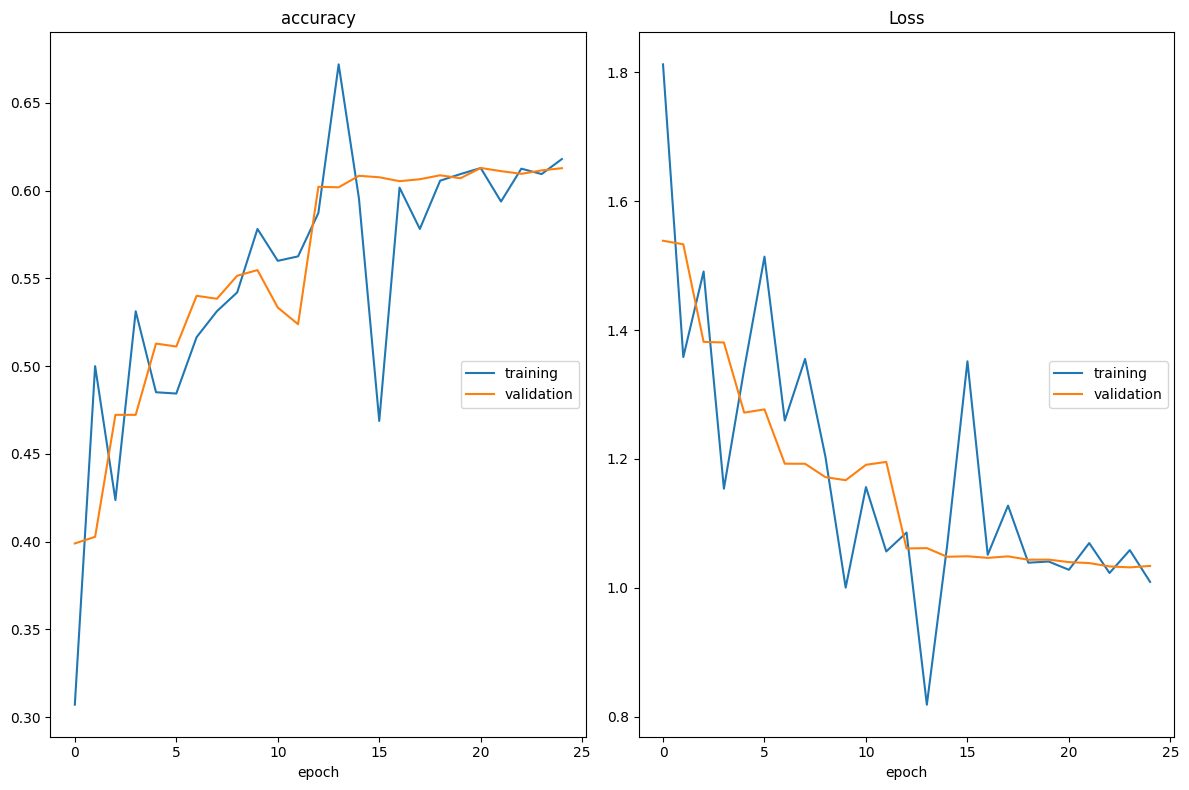

accuracy
	training         	 (min:    0.307, max:    0.672, cur:    0.618)
	validation       	 (min:    0.399, max:    0.613, cur:    0.613)
Loss
	training         	 (min:    0.819, max:    1.812, cur:    1.009)
	validation       	 (min:    1.032, max:    1.539, cur:    1.034)

Epoch 25: saving model to models/model.weights.h5

Epoch 25: finished saving model to models/model.weights.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.6179 - loss: 1.0092 - val_accuracy: 0.6127 - val_loss: 1.0340 - learning_rate: 5.0000e-05
✅ Successfully saved weights to: models/model.weights.h5


In [ ]:
# Setting number of epochs and batch step counts
num_epochs = 15
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = validation_generator.n // validation_generator.batch_size

checkpoint_dir = 'models'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_filename = os.path.join(checkpoint_dir, 'model.weights.h5')

# Checkpoint callback: save best weights based on validation accuracy
checkpoint = ModelCheckpoint(
    checkpoint_filename,
    monitor='val_accuracy',
    save_weights_only=True,
    mode='max',
    verbose=1
)

# Learning rate scheduler: reduce LR on validation loss plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=0.00001,
    mode='auto'
)

# Callbacks list
callbacks = [PlotLossesKerasTF(), checkpoint, reduce_lr]

# Fitting the model
history = model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=num_epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)

# Save the final model weights
model.save_weights('models/model.weights.h5')
model.save_weights('models/model_weights.h5')
print("Model weights successfully saved to models/ directory.")

<a id="63-keras-training-callbacks--reference"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Keras Training Callbacks & Reference</span>

- [Keras Callbacks API Documentation](https://keras.io/api/callbacks/)
- [ReduceLROnPlateau Documentation](https://keras.io/api/callbacks/reduce_lr_on_plateau/)
- [Understanding Verbose Levels in Keras](https://stackoverflow.com/questions/47902295/what-is-the-use-of-verbose-in-keras-while-validating-the-model)

<a id="7-task-6-serialize-model-architecture-to-json"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 6: Serialize Model Architecture to JSON</span>

<a id="71-export-model-architecture-to-json-string"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Export Model Architecture to JSON String</span>

Saving the model architecture as a JSON string allows the network topology to be saved in `models/model.json` independently from trained weights, making lightweight model deployment simple.

In [ ]:
# Converting model topology to JSON string and writing to models/ directory
os.makedirs('models', exist_ok=True)

model_json = model.to_json()
with open('models/model.json', 'w') as json_file:
    json_file.write(model_json)

print("Model architecture successfully saved to models/model.json")

Model architecture successfully saved to models/model.json

📁 Saved artifacts in 'models/' directory:
  - model.json (18,053 bytes)
  - model.weights.h5 (53,813,128 bytes)

⬇️ Triggering automated download of model artifacts from Colab...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<a id="8-task-7-real-time-inference-flask-application"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 7: Real-Time Inference Flask Application</span>

<a id="81-camera-video-stream-processing-srccamerapy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.1 Camera Video Stream Processing (src/camera.py)</span>

In [`src/camera.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/src/camera.py), OpenCV automatically resolves face cascades and captures video from either a local webcam, a video file, or automatic demo simulation mode:

- **Automatic Cascade Resolution**: Checks `models/haarcascade_frontalface_default.xml` and falls back to `cv2.data.haarcascades`.
- **Flexible Source Resolution**: Seamlessly loops video files, connects to webcam device `0`, or falls back to demo simulation mode using `assets/sample_face.jpg` if no physical webcam is detected.

<a id="82-facial-expression-inference-engine-srcmodelpy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.2 Facial Expression Inference Engine (src/model.py)</span>

[`src/model.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/src/model.py) defines `FacialExpressionModel`, loading the architecture from `models/model.json` and weights with modern TensorFlow 2 GPU memory growth:

```python
from src.model import FacialExpressionModel

# Initialize model (auto-detects weights in models/ directory)
model = FacialExpressionModel()
emotion = model.predict_emotion(face_roi_tensor)
```

<a id="83-html-web-interface-template-templatesindexhtml"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.3 HTML Web Interface Template (templates/index.html)</span>

Saved in [`templates/index.html`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/templates/index.html) to render the multipart JPEG video stream rendered by Flask:

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Facial Expression Recognition</title>
</head>
<body style="background-color: #0f1117; display: flex; justify-content: center; align-items: center; min-height: 100vh; margin: 0;">
    <img id="bg" width="800px" height="640px" style="border-radius: 14px; box-shadow: 0 8px 24px rgba(0,0,0,0.6);" src="{{ url_for('video_feed') }}">
</body>
</html>
```

<a id="84-deploy--run-real-time-flask-server-mainpy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.4 Deploy & Run Real-Time Flask Server (main.py)</span>

Execute [`main.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/main.py) to launch the Flask streaming server on `http://localhost:5000`:

In [13]:
# Launching the Flask streaming server
# !python main.py

<a id="9-project-summary--key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Project Summary & Key Takeaways</span>

### Key Takeaways & Pipeline Architecture:

1. **Dataset Pipeline**:
   - Analyzed FER-2013 grayscale dataset ($48 \times 48$ resolution across 7 emotion classes: *Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise*).
   - Identified class imbalance for the `disgust` class (436 samples vs ~4,000+ for others) and addressed representation with real-time horizontal flip data augmentation.
   - Employed `ImageDataGenerator.flow_from_directory` with mini-batches of size 64 and categorical one-hot encoding.

2. **Deep CNN Architecture**:
   - Engineered a 4-block deep convolutional neural network inspired by Goodfellow et al. (2013).
   - Each block incorporates `Conv2D` feature extraction, `BatchNormalization` for internal covariate stabilization, `ReLU` non-linearity, `MaxPooling2D` spatial downsampling, and `Dropout (0.25)` regularization.
   - Dual fully connected dense layers (256 and 512 units) feed into a 7-way `Softmax` output.

3. **Training & Regularization**:
   - Optimized using `Adam(learning_rate=0.0005)` with `categorical_crossentropy` loss.
   - Applied `ModelCheckpoint` to persist best-performing weights (`models/model.weights.h5` / `models/model_weights.h5`) based on peak validation accuracy.
   - Leveraged `ReduceLROnPlateau` for automated learning rate decay and `PlotLossesKerasTF` for live convergence diagnostics.

4. **Production Deployment**:
   - Decoupled model architecture via JSON serialization to `models/model.json`.
   - Built a modular Flask web application streaming processed video frames with OpenCV Haar Cascade face detection and bounding box emotion overlays in real time, featuring automatic demo simulation mode if no camera hardware is present.